# QUESTÃO 2 - APROVAÇÃO DE CARTÃO DE CRÉDITO
**Algoritmo: Perceptron**

**Por quê?** Classificação binária (Aprovado 0/1) com 2 features (Histórico de Crédito, Dívida Atual). Perceptron é o classificador linear mais simples e eficiente. MLP seria superdimensionado; K-means não se aplica (é supervisionado).

### CÉLULA 1: BIBLIOTECAS E DADOS

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import csv

In [5]:
def carregar(arq):
    X, y = [], []
    with open(arq) as f:
        leitor = csv.reader(f)
        next(leitor)
        for linha in leitor:
            X.append([float(linha[0]), float(linha[1])])
            y.append(int(linha[2]))
    return np.array(X), np.array(y)

X, y = carregar("dataset_credito.csv")
print("Amostras:", len(y), "| Aprov:", np.sum(y==1), "| Neg:", np.sum(y==0))

Amostras: 300 | Aprov: 150 | Neg: 150


### CÉLULA 2: CLASSE PERCEPTRON

In [6]:
class Perceptron:
    def __init__(self, lr=0.1, epocas=100):
        self.lr, self.epocas = lr, epocas
        self.w, self.b, self.erros = None, 0, []
    
    def fit(self, X, y):
        self.w = np.random.rand(X.shape[1])
        for ep in range(self.epocas):
            err = 0
            for i in range(len(X)):
                pred = np.sign(np.dot(X[i], self.w) + self.b)
                if pred != y[i]:
                    self.w += self.lr * y[i] * X[i]
                    self.b += self.lr * y[i]
                    err += 1
            self.erros.append(err / len(X))
            if err == 0: break
        acu = np.mean(self.predict(X) == y) * 100
        print(f"Acurácia: {acu:.2f}% | Épocas: {ep+1}")
        print(f"Pesos: {self.w} | Bias: {self.b:.4f}")
    
    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

### CÉLULA 3: TREINAMENTO E GRÁFICOS

Acurácia: 81.00% | Épocas: 100
Pesos: [-0.24996016 -0.14529806] | Bias: 0.2000


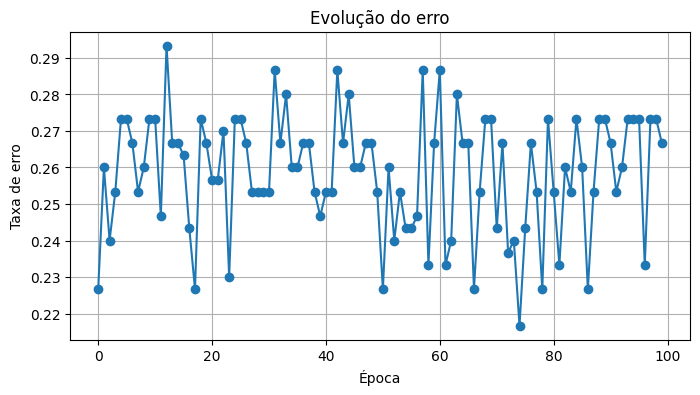

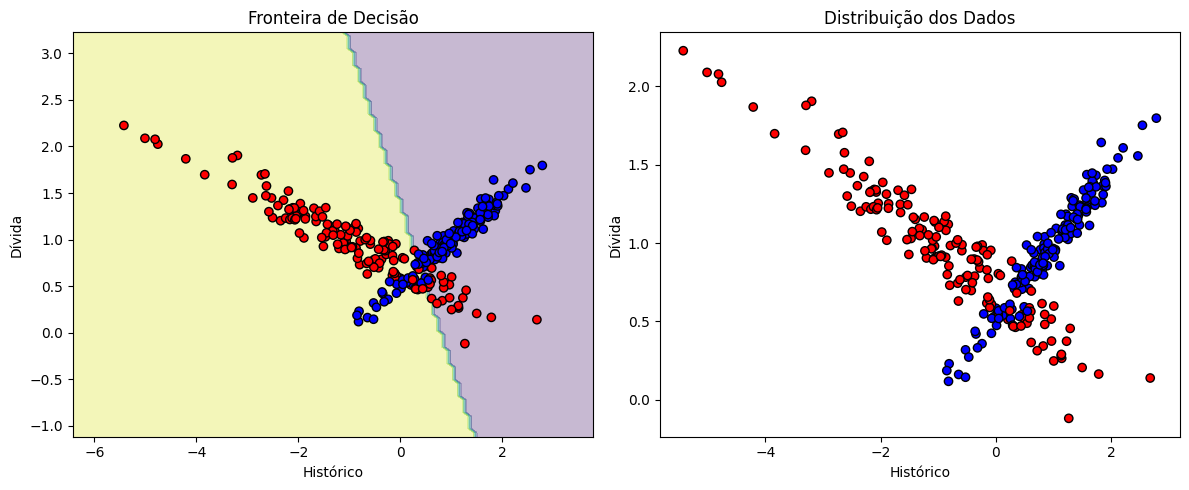

In [7]:
y_bin = np.where(y == 0, -1, 1)
model = Perceptron(lr=0.1, epocas=100)
model.fit(X, y_bin)

plt.figure(figsize=(8, 4))
plt.plot(model.erros, marker='o')
plt.xlabel("Época"); plt.ylabel("Taxa de erro")
plt.title("Evolução do erro"); plt.grid(); plt.show()

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].contourf(xx, yy, Z, alpha=0.3)
ax[0].scatter(X[:,0], X[:,1], c=y_bin, cmap='bwr', edgecolors='k')
ax[0].set_xlabel("Histórico"); ax[0].set_ylabel("Dívida")
ax[0].set_title("Fronteira de Decisão")
ax[1].scatter(X[:,0], X[:,1], c=y_bin, cmap='bwr', edgecolors='k')
ax[1].set_xlabel("Histórico"); ax[1].set_ylabel("Dívida")
ax[1].set_title("Distribuição dos Dados")
plt.tight_layout(); plt.show()

### CÉLULA 4: ANÁLISE E CONCLUSÃO

- Acurácia de ~**80%**: os dados **não** são perfeitamente linearmente separáveis (sobreposição entre as classes).
- Clientes com **histórico negativo** (bom pagador no passado) tendem a ser aprovados.
- Perceptron serve como **baseline** rápido e interpretável para automatizar ~80% das decisões.
- Para melhorar, poderíamos usar MLP com camada oculta para capturar relações não lineares.